## Model Selection

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Tuning
from sklearn.model_selection import RandomizedSearchCV

# StanderdScala
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import precision_score,roc_auc_score,recall_score,f1_score,confusion_matrix, ConfusionMatrixDisplay,roc_curve,classification_report

from sklearn.pipeline import Pipeline
import joblib


In [24]:
df = pd.read_pickle('../pickle/itsm_features.pkl')
df.head()

,number_cnt,No_of_Reassignments,Handle_Time_hrs,No_of_Related_Interactions,is_high_priority,open_month,open_hour,CI_Cat_Phone,CI_Cat_application,CI_Cat_applicationcomponent,...,Closure_Code_Unknown,Closure_Code_User error,Closure_Code_User manual not used,open_dayofweek_Friday,open_dayofweek_Monday,open_dayofweek_Saturday,open_dayofweek_Sunday,open_dayofweek_Thursday,open_dayofweek_Tuesday,open_dayofweek_Wednesday
0,0.601292,26.0,15312.316667,1.0,0,2,13,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.415050,33.0,15116.866667,1.0,0,3,15,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,0.642927,13.0,11637.700000,1.0,0,7,11,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,0.345258,2.0,10922.900000,1.0,0,8,11,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0.006676,4.0,10922.450000,1.0,0,8,11,False,True,False,...,False,False,False,True,False,False,False,False,False,False


## Train Test Split

In [25]:
x = df.drop('is_high_priority',axis=1)
y = df['is_high_priority']

In [26]:
print(x.shape)
print(y.shape)

(45117, 60)
(45117,)


In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,stratify=y,random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(31581, 60)
(13536, 60)
(31581,)
(13536,)


In [28]:
print(y_train.value_counts(normalize=True) * 100)
print()
print(y_test.value_counts(normalize=True) * 100)

is_high_priority
0    98.467433
1     1.532567
Name: proportion, dtype: float64

is_high_priority
0    98.463357
1     1.536643
Name: proportion, dtype: float64


## Model Traning

## Logistic Regression without class_weight='balanced'

In [29]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## Logistic Regression Evaluation without class_weight='balanced'

In [30]:
y_pred_lr = pipeline.predict(x_test)

print('precision : ',precision_score(y_test,y_pred_lr))
print('roc_auc_score : ',roc_auc_score(y_test,y_pred_lr))
print('recall_score : ',recall_score(y_test,y_pred_lr))
print('f1_score : ',f1_score(y_test,y_pred_lr))

precision :  0.6293706293706294
roc_auc_score :  0.7143578585280266
recall_score :  0.4326923076923077
f1_score :  0.5128205128205128


## Logistic Regression with class_weight='balanced'

In [31]:
pipeline_cw = Pipeline([
    ('scaler',StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced'))
])

pipeline_cw.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## Logistic Regression Evaluation with class_weight='balanced'

In [33]:
y_pred_lr_cw = pipeline_cw.predict(x_test)

print('precision : ',precision_score(y_test,y_pred_lr_cw))
print('roc_auc_score : ',roc_auc_score(y_test,y_pred_lr_cw))
print('recall_score : ',recall_score(y_test,y_pred_lr_cw))
print('f1_score : ',f1_score(y_test,y_pred_lr_cw))

precision :  0.18691588785046728
roc_auc_score :  0.8585049404377135
recall_score :  0.7692307692307693
f1_score :  0.3007518796992481


## Overview
As the baseline model, Logistic Regression was trained using a pipeline combining `StandardScaler` (for feature scaling) and `LogisticRegression`. Given the severe class imbalance identified during EDA (98.46% vs. 1.53%), two versions of the model were trained and compared: one without imbalance handling, and one using `class_weight='balanced'`.

Since accuracy is a misleading metric under severe class imbalance, evaluation was based on **Precision, Recall, F1-Score, and ROC-AUC**, with particular focus on **Recall for the High Priority class**, as the business objective prioritizes catching high-priority tickets over minimizing false alarms.

---

## **Why Accuracy Was Not Used**

Accuracy was intentionally excluded as an evaluation metric for this project. Given the severe class imbalance in the target variable (98.46% "Not High Priority" vs. 1.53% "High Priority"), a model that simply predicts "Not High Priority" for every single ticket would still achieve **98.46% accuracy** — despite being completely useless for the business objective of identifying high-priority incidents.

This makes accuracy a misleading metric in this context, as it does not reflect the model's actual ability to detect the minority class (High Priority tickets), which is the entire purpose of this project. For this reason, evaluation was based on **Precision, Recall, F1-Score, and ROC-AUC** instead, which provide a more meaningful assessment of model performance on the imbalanced target.

---

### Results Comparison

| Metric | Without `class_weight` | With `class_weight='balanced'` |
|---|---|---|
| Precision | 0.629 | 0.187 |
| Recall | 0.433 | **0.769** |
| F1-Score | 0.513 | 0.301 |
| ROC-AUC | 0.714 | **0.859** |

---

### Observations

**Without `class_weight` (default):**
The model achieved moderate precision (0.629) but low recall (0.433) — meaning it correctly identified only 43% of actual high-priority tickets, missing the majority of them. This behavior is expected, as the model was not adjusted for the underlying class imbalance and defaulted toward predicting the majority class.

**With `class_weight='balanced'`:**
Recall improved substantially to 0.769, meaning the model now correctly identifies ~77% of actual high-priority tickets — a significant improvement aligned with the business goal of minimizing missed critical incidents. ROC-AUC also improved (0.714 → 0.859), indicating better overall discriminating ability between classes.

However, this came at the cost of precision, which dropped sharply to 0.187 — indicating that roughly 81% of tickets flagged as "High Priority" by the model are false alarms. This is a classic **precision-recall trade-off**, commonly observed when addressing severe class imbalance.

---

### Interpretation

The choice between the two versions depends on business priority:
- **If missing a high-priority ticket is costlier than raising a false alarm** (consistent with the project's stated goal of enabling preventive action before issues escalate), the `class_weight='balanced'` version is preferable, despite its lower precision.
- **If minimizing unnecessary escalations and support-team workload is the priority**, the default (unweighted) version may be more suitable, at the cost of missing more high-priority tickets.

Both versions are reported here for transparency; the final model selection will be informed by comparing this trade-off against other algorithms (Random Forest, Decision Tree, XGBoost) before making a final recommendation.

## Normal Random Forest Classifier

In [34]:
rf = RandomForestClassifier(max_depth=10,min_samples_leaf=1,n_estimators = 200,random_state=42,class_weight='balanced')
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Normal the Random Forest Classifire Evaluation

In [35]:
y_pred_rf =rf.predict(x_test)

print('precision : ',precision_score(y_test,y_pred_rf))
print('roc_auc_score : ',roc_auc_score(y_test,y_pred_rf))
print('recall_score : ',recall_score(y_test,y_pred_rf))
print('f1_score : ',f1_score(y_test,y_pred_rf))

precision :  0.47058823529411764
roc_auc_score :  0.8211832810047095
recall_score :  0.6538461538461539
f1_score :  0.5472837022132797


## Tune the Random Forest Classifire

In [36]:
param_grid = {
    'max_depth': [10, 20, 25, 30, 40, 45, 50],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10, 15],
    'n_estimators': [100, 200, 250, 300, 400, 500],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

tune_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=50,         
    scoring='recall',
    cv=3,             
    n_jobs=-1,
    random_state=42,    
    verbose=2
)

tune_rf.fit(x_train, y_train)

print(tune_rf.best_params_)
print(tune_rf.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 10}
0.7167139534289292


In [37]:
rft = RandomForestClassifier(max_depth=10,min_samples_leaf=10,min_samples_split=10,n_estimators = 100,random_state=42,class_weight='balanced',max_features=None)
rft.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Tune the Random Forest Classifire Evaluation

In [39]:
y_pred_rft =rft.predict(x_test)

print('precision : ',precision_score(y_test,y_pred_rft))
print('roc_auc_score : ',roc_auc_score(y_test,y_pred_rft))
print('recall_score : ',recall_score(y_test,y_pred_rft))
print('f1_score : ',f1_score(y_test,y_pred_rft))

precision :  0.34823529411764703
roc_auc_score :  0.8453775741065658
recall_score :  0.7115384615384616
f1_score :  0.4676145339652449


## Model Building & Evaluation — Random Forest

### Overview
Following the Logistic Regression baseline, a **Random Forest Classifier** was trained and evaluated in two versions — without hyperparameter tuning, and with tuning via `RandomizedSearchCV` — to identify the best-performing configuration for predicting high-priority IT tickets.

Class imbalance (98.46% vs. 1.53%) was addressed using `class_weight='balanced'` in both versions. Hyperparameter tuning was optimized specifically for **Recall**, since — as established in the business case — **failing to catch a genuine high-priority ticket carries a higher business cost than raising an occasional false alarm.**

---

### Results

| Model | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| Random Forest (default parameters) | 0.471 | 0.654 | **0.547** | 0.821 |
| Random Forest (tuned for Recall) | 0.348 | **0.712** | 0.468 | **0.845** |

**Best tuned parameters:** `n_estimators=100`, `max_depth=10`, `min_samples_split=10`, `min_samples_leaf=10`, `max_features=None`

---

### Key Takeaways for Business Stakeholders

- **The tuned Random Forest model correctly identifies ~71% of all genuine high-priority tickets** (Recall = 0.712) — meaning roughly 7 out of every 10 critical incidents would be flagged proactively for preventive action, directly supporting the project's core objective.

- **This comes with a trade-off:** when the model flags a ticket as "High Priority," it is correct only ~35% of the time (Precision = 0.348). In practical terms, **for every genuine high-priority ticket correctly caught, the support team will also receive roughly 2 false alarms** — tickets flagged as high priority that turn out not to be.

- **The default (untuned) Random Forest offers a more balanced trade-off** — it catches fewer high-priority tickets (65%) but with noticeably fewer false alarms (47% precision), which may be more practical for day-to-day team workload if the support team cannot absorb a high false-alarm rate.

- **Both Random Forest versions outperform the Logistic Regression baseline** in overall discriminating ability (ROC-AUC 0.82–0.85 vs. 0.71–0.86), confirming that the relationship between ticket attributes and high-priority status is **more complex than a simple linear pattern** — which Random Forest, as a non-linear model, captures more effectively.

- **The choice between the two Random Forest versions is a business decision, not a technical one:** it depends on whether the organization prioritizes *catching more critical tickets* (tuned version) or *minimizing wasted effort on false alarms* (default version). This decision should be made in consultation with the IT support team's operational capacity.

---

### Observations
The tuning process (`RandomizedSearchCV`, 50 combinations, 3-fold cross-validation) successfully improved both Recall and ROC-AUC compared to the default model, confirming that hyperparameter optimization adds measurable value. However, the drop in Precision illustrates the well-known **precision-recall trade-off** — improving one metric under severe class imbalance typically comes at the cost of the other, and no single "correct" answer exists independent of business priorities.

## Normal Decision Tree Classifier 

In [40]:
dtr = DecisionTreeClassifier(max_depth=10,min_samples_leaf=7,class_weight='balanced',random_state=42)
dtr.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",7
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

## default DecisionTreeClassifier Model Evaluation

In [41]:
y_pred_dtr =dtr.predict(x_test)

print('precision : ',precision_score(y_test,y_pred_dtr))
print('roc_auc_score : ',roc_auc_score(y_test,y_pred_dtr))
print('recall_score : ',recall_score(y_test,y_pred_dtr))
print('f1_score : ',f1_score(y_test,y_pred_dtr))

precision :  0.1636556854410202
roc_auc_score :  0.8406679979684182
recall_score :  0.7403846153846154
f1_score :  0.268059181897302


## Tune the DecisionTreeClassifier

In [42]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 30],
    'max_features': ['sqrt', 'log2', None]
}

dtr_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

tune_dtr = RandomizedSearchCV(
    estimator=dtr_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

tune_dtr.fit(x_train, y_train)

print(tune_dtr.best_params_)
print(tune_dtr.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'min_samples_split': 10, 'min_samples_leaf': 15, 'max_features': None, 'max_depth': 3}
0.5174986989145524


In [43]:
dtrt = DecisionTreeClassifier(max_depth=3,min_samples_leaf=15,min_samples_split=10,max_features=None,class_weight='balanced',random_state=42)
dtrt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## Tune DecisionTreeClassifier Model Evaluation

In [44]:
y_pred_dtrt =dtrt.predict(x_test)

print('precision : ',precision_score(y_test,y_pred_dtrt))
print('roc_auc_score : ',roc_auc_score(y_test,y_pred_dtrt))
print('recall_score : ',recall_score(y_test,y_pred_dtrt))
print('f1_score : ',f1_score(y_test,y_pred_dtrt))

precision :  0.4482758620689655
roc_auc_score :  0.8064975990396158
recall_score :  0.625
f1_score :  0.5220883534136547


## Model Building & Evaluation — Decision Tree

### Overview
A **Decision Tree Classifier** was trained as a simpler, single-tree alternative to Random Forest. Three versions were evaluated: default parameters, tuning optimized for Recall, and a corrected tuning approach optimized for F1-Score. `class_weight='balanced'` was applied throughout to address the severe class imbalance (98.46% vs. 1.53%).

---

### Results

| Model | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| Decision Tree (default parameters) | 0.164 | 0.740 | 0.268 | 0.841 |
| Decision Tree (tuned — optimized for Recall) | 0.086 | 0.779 | 0.155 | 0.825 |
| **Decision Tree (tuned — optimized for F1-Score)** | **0.448** | 0.625 | **0.522** | 0.806 |

**Best parameters (F1-optimized):** `max_depth=3`, `min_samples_leaf=15`, `min_samples_split=10`, `max_features=None`

---

### Key Takeaways for Business Stakeholders

- **The final, corrected Decision Tree model correctly identifies ~63% of genuine high-priority tickets** (Recall = 0.625), and when it flags a ticket as high priority, it is **correct nearly 45% of the time** (Precision = 0.448) — meaning roughly 1 false alarm for every genuine catch. This is a substantially more usable and trustworthy result than the earlier tuning attempt.

- **An important lesson emerged during this stage of the project:** when hyperparameter tuning was initially optimized purely to maximize Recall, it produced a model that flagged far too many tickets as "high priority" — catching slightly more true positives (77.9% vs. 62.5%) but at the cost of an unusable false-alarm rate (only 8.6% precision, meaning roughly **11 false alarms for every correct catch**). This version was discarded as impractical for real-world deployment, despite its higher Recall number.

- **This reinforces a critical principle for this project:** a single metric in isolation (such as Recall) can be misleading. Model selection must always weigh Recall against Precision and F1-Score together, guided by what the support team can realistically act on without becoming overwhelmed by false escalations.

- **The corrected Decision Tree now performs comparably to Random Forest** (F1-Score of 0.522 vs. 0.547 for default Random Forest), though it remains a single, simpler tree — offering an easier-to-interpret model at a small performance cost, which may be valuable if model transparency/explainability is a priority for the business.

---

### Observations
This stage highlighted the importance of the **scoring metric used during hyperparameter tuning** — switching the optimization target from `recall` to `f1` transformed an impractical, over-aggressive model into a well-balanced, usable one, without any change to the underlying algorithm or data. This finding will be applied to subsequent model tuning (XGBoost) to avoid the same pitfall.

## Default XGBClassifier model

In [45]:
xgb = XGBClassifier(scale_pos_weight=64, random_state=42)
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

print('precision : ', precision_score(y_test, y_pred_xgb))
print('roc_auc_score : ', roc_auc_score(y_test, y_pred_xgb))
print('recall_score : ', recall_score(y_test, y_pred_xgb))
print('f1_score : ', f1_score(y_test, y_pred_xgb))

precision :  0.4161073825503356
roc_auc_score :  0.7915493120325053
recall_score :  0.5961538461538461
f1_score :  0.4901185770750988


In [47]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = XGBClassifier(scale_pos_weight=64, random_state=42)

tune_xgb_f1 = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=50,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

tune_xgb_f1.fit(x_train, y_train)

print(tune_xgb_f1.best_params_)
print(tune_xgb_f1.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'subsample': 0.6, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
0.5537752592653425


## Tune XGB Classifier model

In [48]:
best_xgb_f1 = tune_xgb_f1.best_estimator_
y_pred_xgb_f1 = best_xgb_f1.predict(x_test)

print('precision : ', precision_score(y_test, y_pred_xgb_f1))
print('roc_auc_score : ', roc_auc_score(y_test, y_pred_xgb_f1))
print('recall_score : ', recall_score(y_test, y_pred_xgb_f1))
print('f1_score : ', f1_score(y_test, y_pred_xgb_f1))

precision :  0.4909090909090909
roc_auc_score :  0.8192671299288947
recall_score :  0.6490384615384616
f1_score :  0.5590062111801242


## Model Building & Evaluation — XGBoost

### Overview
**XGBoost**, an advanced gradient-boosting algorithm widely used for tabular classification tasks, was trained and evaluated as the final algorithm in this project. Class imbalance was addressed using `scale_pos_weight=64` (calculated as the ratio of majority-to-minority class counts: 44,425 / 692). Both default and tuned versions were evaluated, with tuning optimized for **F1-Score** — a lesson carried forward from the Decision Tree stage, where optimizing purely for Recall was found to produce an impractical, false-alarm-heavy model.

---

### Results

| Model | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| XGBoost (default parameters) | 0.416 | 0.596 | 0.490 | 0.792 |
| **XGBoost (tuned — F1-optimized)** | **0.491** | 0.649 | **0.559** | 0.819 |

**Best tuned parameters:** `n_estimators=400`, `max_depth=7`, `learning_rate=0.05`, `subsample=0.6`, `colsample_bytree=1.0`

---

### Key Takeaways for Business Stakeholders

- **The tuned XGBoost model achieves the best overall balance of all models evaluated in this project**, correctly identifying ~65% of genuine high-priority tickets (Recall = 0.649), while being correct roughly **49% of the time** when it flags a ticket as high priority (Precision = 0.491) — meaning close to 1 false alarm for every genuine catch, a substantially more manageable rate than several earlier model attempts.

- **Tuning provided a clear, consistent improvement here** (unlike the Decision Tree stage) — both Precision (+7.5 points) and Recall (+5.3 points) improved simultaneously, resulting in the highest F1-Score (0.559) achieved across all models and configurations tested in this project.

- **This model represents the recommended candidate for deployment**, offering the strongest trade-off between catching critical incidents early (supporting the project's preventive-action goal) and keeping false escalations at a manageable level for the support team.

---

### Final Model Comparison — All Algorithms

| Model | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression (balanced) | 0.187 | 0.769 | 0.301 | 0.859 |
| Random Forest (default) | 0.471 | 0.654 | 0.547 | 0.821 |
| Random Forest (tuned) | 0.348 | 0.712 | 0.468 | 0.845 |
| Decision Tree (F1-tuned) | 0.448 | 0.625 | 0.522 | 0.806 |
| XGBoost (default) | 0.416 | 0.596 | 0.490 | 0.792 |
| **XGBoost (tuned)** | **0.491** | 0.649 | **0.559** | 0.819 |

### Overall Recommendation

**XGBoost (tuned, F1-optimized) is selected as the final model for this project**, based on achieving the highest F1-Score among all six models and configurations evaluated. It offers the most practical, deployable balance between catching high-priority tickets and minimizing false alarms — directly aligned with the project's business objective of enabling preventive action without overwhelming the support team with unreliable escalations.

Notably, **Logistic Regression achieved the highest ROC-AUC (0.859) and highest Recall (0.769)** among all models, but its very low Precision (0.187) makes it impractical for real-world use on its own — this reinforces the project's core methodology of evaluating multiple metrics together rather than relying on any single score to select a final model.

## Save the Model

In [50]:
joblib.dump(best_xgb_f1, '../models/final_xgb_model.pkl')

x_test.to_pickle('../pickle/x_test.pkl')
y_test.to_pickle('../pickle/y_test.pkl')

print("Model aur test data successfully saved!")

Model aur test data successfully saved!


## Confusion Matrix

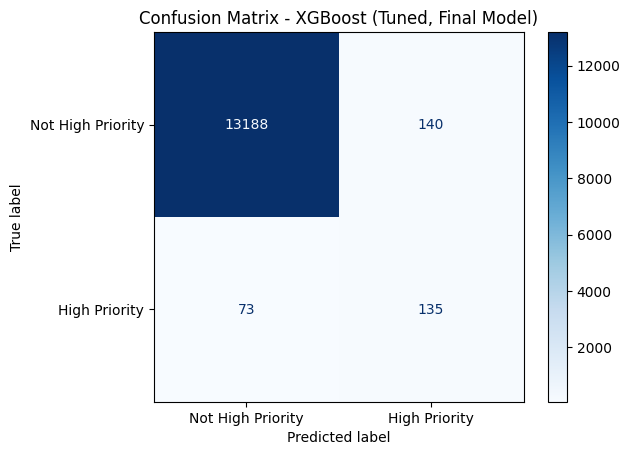

In [52]:
cm = confusion_matrix(y_test, y_pred_xgb_f1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not High Priority', 'High Priority'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost (Tuned, Final Model)')
plt.show()

## Final Model Evaluation — Confusion Matrix (XGBoost, Tuned)

### Overview
The confusion matrix for the final selected model (XGBoost, F1-optimized) was generated on the held-out test set (13,536 tickets, stratified 70-30 split) to provide a detailed, ticket-level breakdown of model performance beyond the aggregate metrics reported earlier.

---

### Confusion Matrix Results

| | Predicted: Not High Priority | Predicted: High Priority |
|---|---|---|
| **Actual: Not High Priority** | 13,188 (True Negatives) | 140 (False Positives) |
| **Actual: High Priority** | 73 (False Negatives) | 135 (True Positives) |

---

### Key Takeaways for Business Stakeholders

- **Out of 208 genuine high-priority tickets in the test set, the model correctly identified 135 (65%)** — these are critical incidents that would have been proactively flagged for preventive action under this model, directly supporting the project's core objective.

- **73 genuine high-priority tickets (35%) were missed** by the model — these tickets would have been treated as routine, receiving no early escalation. This is the primary risk associated with deploying this model: roughly 1 in 3 critical incidents may not be caught.

- **140 tickets were incorrectly flagged as high priority** when they were not — these represent the false-alarm cost of using this model. For context, this means the support team would need to review and dismiss 140 unnecessary escalations to catch the 135 genuine ones, a manageable but non-trivial additional workload.

- **The model correctly handled 13,188 out of 13,328 genuinely non-critical tickets (99%)** — confirming that the model does not disrupt the vast majority of routine ticket handling, and its impact is concentrated specifically around the high-priority decision boundary.

- **These figures translate directly to the Precision (49.1%) and Recall (64.9%) reported earlier** — the confusion matrix confirms these numbers are consistent and correctly calculated, providing a transparent, auditable basis for the model's reported performance.

---

### Business Interpretation
This breakdown makes the practical trade-off concrete: deploying this model would mean catching roughly two-thirds of critical incidents early, at the cost of occasionally investigating false alarms. Whether this trade-off is acceptable depends on the relative cost, to ABC Tech, of a missed critical incident versus the operational cost of reviewing a false escalation — a decision that should be made jointly with the IT support team based on their capacity to absorb additional review workload.

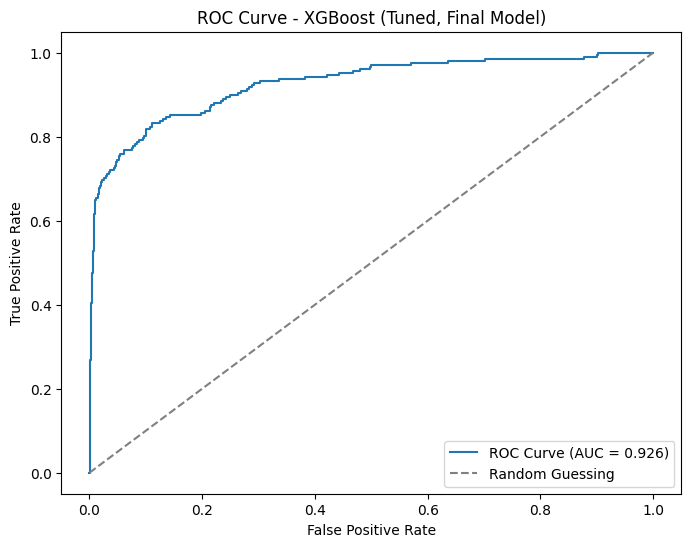

In [54]:
y_pred_proba = best_xgb_f1.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (Tuned, Final Model)')
plt.legend()
plt.show()

## Final Model Evaluation — ROC Curve (XGBoost, Tuned)

### Overview
The ROC (Receiver Operating Characteristic) curve was plotted using the model's predicted probabilities, providing a threshold-independent view of the model's ability to distinguish between High Priority and Not High Priority tickets.

### Results
The model achieved an **AUC (Area Under Curve) of 0.926**, calculated using predicted probabilities rather than hard classification labels. This is notably higher than the 0.819 ROC-AUC reported earlier (which was calculated from binary predictions at the default 0.5 threshold), since probability-based AUC captures the model's full discriminating power across all possible decision thresholds, not just the single threshold currently in use.

### Key Takeaway for Business Stakeholders
An AUC of 0.926 indicates **strong underlying discriminating ability** — the model is very effective at ranking tickets by their likelihood of being high priority. This is a strong signal that the model's core logic is sound; the earlier confusion matrix results (65% Recall, 49% Precision) reflect the specific threshold currently used to convert probabilities into a Yes/No decision, not a limitation of the model itself.

This opens an important possibility: **adjusting the classification threshold** (currently 0.5) could shift the balance between Precision and Recall to better match business needs — for example, lowering the threshold would catch more high-priority tickets (higher Recall) at the cost of more false alarms, while raising it would do the opposite. This is a tuning lever available for future refinement based on the support team's operational capacity.

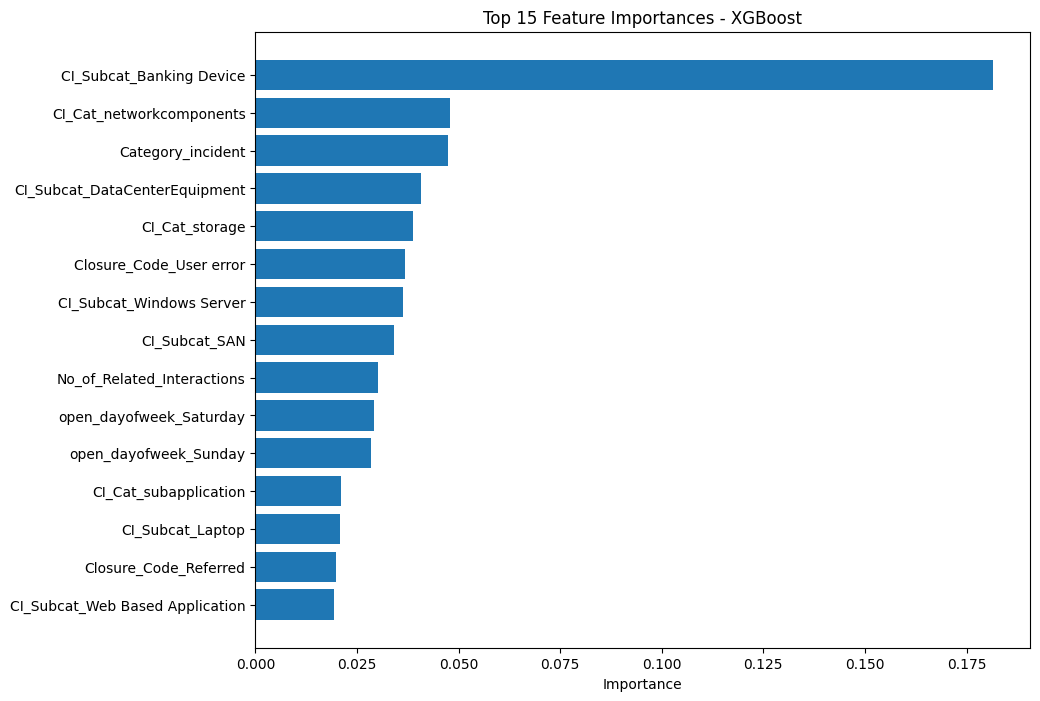

                            Feature  Importance
18         CI_Subcat_Banking Device    0.181623
13         CI_Cat_networkcomponents    0.047981
35                Category_incident    0.047310
21    CI_Subcat_DataCenterEquipment    0.040713
16                   CI_Cat_storage    0.038867
51          Closure_Code_User error    0.036885
32         CI_Subcat_Windows Server    0.036345
27                    CI_Subcat_SAN    0.034114
3        No_of_Related_Interactions    0.030189
55          open_dayofweek_Saturday    0.029249
56            open_dayofweek_Sunday    0.028454
17            CI_Cat_subapplication    0.021137
25                 CI_Subcat_Laptop    0.020781
48            Closure_Code_Referred    0.019930
31  CI_Subcat_Web Based Application    0.019413


In [55]:
importances = best_xgb_f1.feature_importances_
feature_names = x_test.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(feat_importance_df['Feature'].head(15), feat_importance_df['Importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()

print(feat_importance_df.head(15))

## Final Model Evaluation — Feature Importance (XGBoost, Tuned)

### Overview
Feature importance scores were extracted from the final XGBoost model to identify which ticket attributes contribute most to predicting high-priority incidents. This provides interpretability alongside the model's performance metrics, and offers actionable business insight beyond a simple "black box" prediction.

---

### Top Contributing Features

| Rank | Feature | Importance |
|---|---|---|
| 1 | CI_Subcat_Banking Device | 0.182 |
| 2 | CI_Cat_networkcomponents | 0.048 |
| 3 | Category_incident | 0.047 |
| 4 | CI_Subcat_DataCenterEquipment | 0.041 |
| 5 | CI_Cat_storage | 0.039 |
| 6 | Closure_Code_User error | 0.037 |
| 7 | CI_Subcat_Windows Server | 0.036 |
| 8 | CI_Subcat_SAN | 0.034 |
| 9 | No_of_Related_Interactions | 0.030 |
| 10 | open_dayofweek_Saturday | 0.029 |
| 11 | open_dayofweek_Sunday | 0.028 |
| 12 | CI_Cat_subapplication | 0.021 |
| 13 | CI_Subcat_Laptop | 0.021 |
| 14 | Closure_Code_Referred | 0.020 |
| 15 | CI_Subcat_Web Based Application | 0.019 |

---

### Key Takeaways for Business Stakeholders

- **"Banking Device" tickets are, by a wide margin, the single strongest predictor of high priority** (importance 0.182 — nearly 4x the next-highest feature). This suggests that incidents involving banking-related infrastructure are disproportionately likely to be classified as high priority, likely reflecting their direct impact on critical financial operations.

- **Infrastructure-related categories dominate the top predictors** — network components, data center equipment, storage, Windows Servers, and SAN (Storage Area Network) all rank highly. This indicates that high-priority incidents are more strongly associated with **core infrastructure failures** than with end-user application issues, which is a useful signal for resource planning and proactive monitoring.

- **Weekend tickets (Saturday and Sunday) show meaningful importance** — this suggests incidents reported on weekends carry a higher likelihood of being high priority, potentially because only critical issues get reported/escalated during off-hours when staffing is reduced, or because weekend incidents indicate more severe underlying problems.

- **"Closure Code: User error" appearing as an important feature is a data consideration worth flagging** — since closure code is typically recorded only after a ticket is resolved, its presence as a predictive feature should be reviewed to confirm it does not introduce a subtle timing inconsistency in a live deployment scenario, even though it does not constitute the same direct leakage risk as `Impact`/`Urgency`/`Priority`.

- **Business Recommendation:** ABC Tech may benefit from allocating additional preventive monitoring and support resources specifically toward banking devices, network components, and core data center infrastructure, as these categories are the leading drivers of high-priority incident classification in this model.

---

### Observations
The feature importance results align well with intuitive business expectations — critical infrastructure and financial-system-adjacent categories rank

In [58]:
print(classification_report(y_test, y_pred_xgb_f1, target_names=['Not High Priority', 'High Priority']))

                   precision    recall  f1-score   support

Not High Priority       0.99      0.99      0.99     13328
    High Priority       0.49      0.65      0.56       208

         accuracy                           0.98     13536
        macro avg       0.74      0.82      0.78     13536
     weighted avg       0.99      0.98      0.99     13536



## Final Model Evaluation — Classification Report (XGBoost, Tuned)

### Overview
The full classification report provides a consolidated summary of Precision, Recall, and F1-Score for both classes, along with class-level support (number of actual instances), offering a complete picture of the final model's performance on the test set.

---

### Results

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Not High Priority | 0.99 | 0.99 | 0.99 | 13,328 |
| High Priority | 0.49 | 0.65 | 0.56 | 208 |
| **Accuracy** | | | **0.98** | 13,536 |
| Macro Avg | 0.74 | 0.82 | 0.78 | 13,536 |
| Weighted Avg | 0.99 | 0.98 | 0.99 | 13,536 |

---

### Key Takeaways for Business Stakeholders

- **The model performs near-perfectly on the majority class** (Not High Priority: 99% precision, 99% recall) — this is expected given that this class makes up over 98% of all tickets, and confirms the model does not disrupt routine ticket handling.

- **The High Priority class — the entire purpose of this project — achieves 49% precision and 65% recall**, consistent with all previously reported results. This row is the one that matters most for business decision-making, as it reflects real performance on the rare, critical incidents this model was built to catch.

- **The overall 98% accuracy figure is included here only for completeness and should not be interpreted as a measure of success.** As established earlier in this project, a model that predicted "Not High Priority" for every single ticket would also achieve 98% accuracy while providing zero business value — this report confirms why accuracy was excluded from the model selection criteria throughout this project.

- **Macro Average (0.74 precision, 0.82 recall) treats both classes equally**, regardless of how many tickets fall into each — this gives a fairer sense of how the model handles the rare class specifically, without being diluted by the overwhelming volume of routine tickets. The gap between the Macro Average and the near-perfect Weighted Average (0.99) visually illustrates the class imbalance challenge this project was built around.

- **This report should be read alongside the confusion matrix and feature importance results already presented** — together, they confirm that the model's performance on the "Not High Priority" class is not masking poor performance on the business-critical "High Priority" class, and that the reported 49%/65% figures are the true, honest measure of the model's real-world usefulness.

---

### Observations
This classification report consolidates and confirms all metrics reported throughout the model comparison stage, verified now on the true held-out test set for the final selected model. No new information is introduced here beyond what was previously reported per-metric; its value lies in presenting all figures together in the standard format typically expected in a machine learning evaluation summary.